In [2]:
#import python libraries
import pandas as pd 
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import yaml
import os

In [3]:
# load config yaml file
yaml_file_path = os.path.join(os.getcwd(), "../config.yaml")
with open(yaml_file_path, 'r') as file:
    data = yaml.safe_load(file)

In [6]:
normalize_file_path = data['gbm_clean_file_paths']['final_genomic_data_file_name']
min_max_file = normalize_file_path + "/normalized_minmax_gbm.csv"
zscore_file = normalize_file_path + "/normalized_zscore_gbm.csv"

min_max = pd.read_csv(min_max_file)
zscore = pd.read_csv(zscore_file)


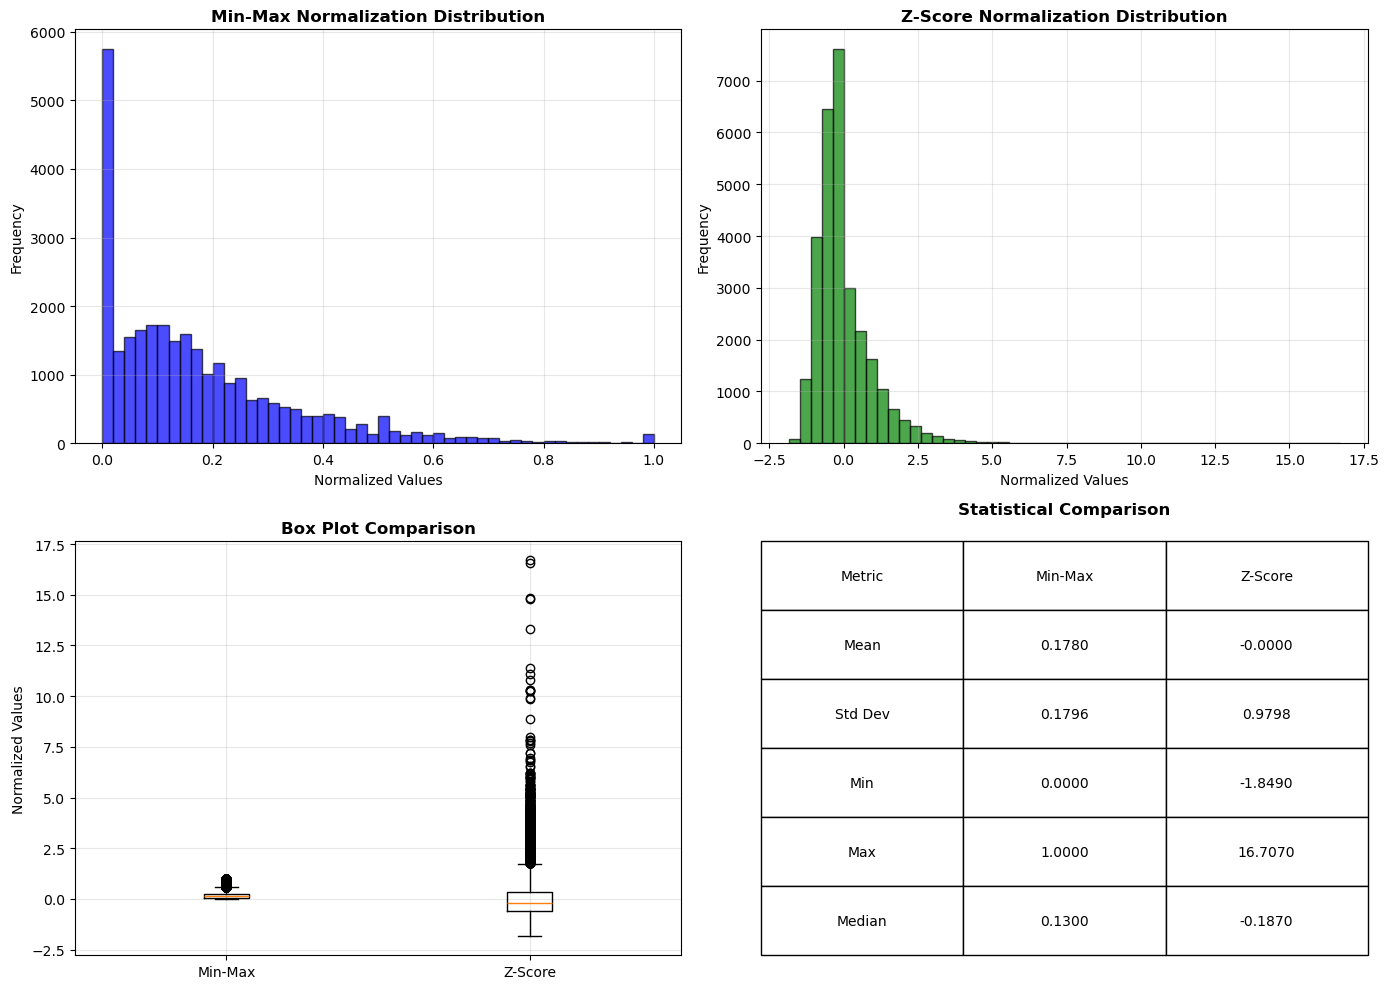

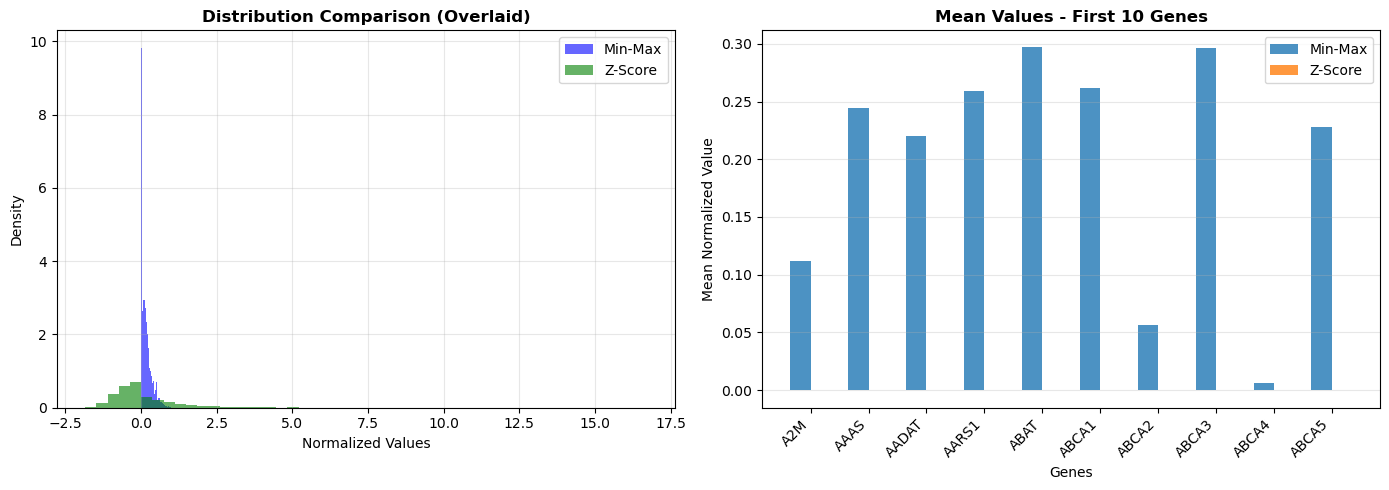

NORMALIZATION METHODS COMPARISON

Min-Max Normalization (First 100 genes, 29300 values):
  Mean: 0.178026
  Std Dev: 0.179603
  Min: 0.000000
  Max: 1.000000
  Q1 (25%): 0.042000
  Median: 0.130000
  Q3 (75%): 0.256000

Z-Score Normalization (First 100 genes, 29300 values):
  Mean: -0.000009
  Std Dev: 0.979802
  Min: -1.849000
  Max: 16.707000
  Q1 (25%): -0.617000
  Median: -0.187000
  Q3 (75%): 0.329000

COMPARISON SUMMARY:
✓ Min-Max: Scales values to [0, 1] range - RANGE-BASED normalization
✓ Z-Score: Standardizes values with mean≈0, std≈1 - DISTRIBUTION-BASED normalization


In [13]:
# Set up matplotlib for display
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 10)

# Convert to numeric and handle any non-numeric columns
min_max_numeric = min_max.copy()
zscore_numeric = zscore.copy()

# Drop non-numeric columns and convert to numeric
for df in [min_max_numeric, zscore_numeric]:
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df.dropna(axis=1, how='all', inplace=True)

# Get first 100 genes for visualization
n_genes = min(100, min_max_numeric.shape[1])

# Get data for plotting
min_max_data = min_max_numeric.iloc[:, :n_genes].values.flatten()
zscore_data = zscore_numeric.iloc[:, :n_genes].values.flatten()

# Remove NaN values
min_max_data = min_max_data[~np.isnan(min_max_data)]
zscore_data = zscore_data[~np.isnan(zscore_data)]

# 1. Distribution Comparison
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Min-Max Distribution
ax1.hist(min_max_data, bins=50, alpha=0.7, color='blue', edgecolor='black')
ax1.set_title('Min-Max Normalization Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Normalized Values')
ax1.set_ylabel('Frequency')
ax1.grid(alpha=0.3)

# Z-Score Distribution
ax2.hist(zscore_data, bins=50, alpha=0.7, color='green', edgecolor='black')
ax2.set_title('Z-Score Normalization Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Normalized Values')
ax2.set_ylabel('Frequency')
ax2.grid(alpha=0.3)

# Box Plot Comparison
box_data = [min_max_data, zscore_data]
ax3.boxplot(box_data, tick_labels=['Min-Max', 'Z-Score'])
ax3.set_title('Box Plot Comparison', fontsize=12, fontweight='bold')
ax3.set_ylabel('Normalized Values')
ax3.grid(alpha=0.3)

# Statistics Table
stats_data = {
    'Metric': ['Mean', 'Std Dev', 'Min', 'Max', 'Median'],
    'Min-Max': [
        f"{min_max_data.mean():.4f}",
        f"{min_max_data.std():.4f}",
        f"{min_max_data.min():.4f}",
        f"{min_max_data.max():.4f}",
        f"{np.median(min_max_data):.4f}"
    ],
    'Z-Score': [
        f"{zscore_data.mean():.4f}",
        f"{zscore_data.std():.4f}",
        f"{zscore_data.min():.4f}",
        f"{zscore_data.max():.4f}",
        f"{np.median(zscore_data):.4f}"
    ]
}

ax4.axis('off')
stats_df = pd.DataFrame(stats_data)
table = ax4.table(cellText=stats_df.values, colLabels=stats_df.columns, 
                  cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
ax4.set_title('Statistical Comparison', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# 2. Density Plot Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(min_max_data, bins=50, density=True, alpha=0.6, color='blue', label='Min-Max')
ax1.hist(zscore_data, bins=50, density=True, alpha=0.6, color='green', label='Z-Score')
ax1.set_title('Distribution Comparison (Overlaid)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Normalized Values')
ax1.set_ylabel('Density')
ax1.legend()
ax1.grid(alpha=0.3)

# Sample genes comparison
sample_genes = min_max_numeric.columns[:10]
x = np.arange(len(sample_genes))
width = 0.35

min_max_means = min_max_numeric[sample_genes].mean()
zscore_means = zscore_numeric[sample_genes].mean()

ax2.bar(x - width/2, min_max_means, width, label='Min-Max', alpha=0.8)
ax2.bar(x + width/2, zscore_means, width, label='Z-Score', alpha=0.8)
ax2.set_title('Mean Values - First 10 Genes', fontsize=12, fontweight='bold')
ax2.set_xlabel('Genes')
ax2.set_ylabel('Mean Normalized Value')
ax2.set_xticks(x)
ax2.set_xticklabels(sample_genes, rotation=45, ha='right')
ax2.legend()
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("=" * 70)
print("NORMALIZATION METHODS COMPARISON")
print("=" * 70)
print(f"\nMin-Max Normalization (First {n_genes} genes, {len(min_max_data)} values):")
print(f"  Mean: {min_max_data.mean():.6f}")
print(f"  Std Dev: {min_max_data.std():.6f}")
print(f"  Min: {min_max_data.min():.6f}")
print(f"  Max: {min_max_data.max():.6f}")
print(f"  Q1 (25%): {np.percentile(min_max_data, 25):.6f}")
print(f"  Median: {np.percentile(min_max_data, 50):.6f}")
print(f"  Q3 (75%): {np.percentile(min_max_data, 75):.6f}")

print(f"\nZ-Score Normalization (First {n_genes} genes, {len(zscore_data)} values):")
print(f"  Mean: {zscore_data.mean():.6f}")
print(f"  Std Dev: {zscore_data.std():.6f}")
print(f"  Min: {zscore_data.min():.6f}")
print(f"  Max: {zscore_data.max():.6f}")
print(f"  Q1 (25%): {np.percentile(zscore_data, 25):.6f}")
print(f"  Median: {np.percentile(zscore_data, 50):.6f}")
print(f"  Q3 (75%): {np.percentile(zscore_data, 75):.6f}")

print("\n" + "=" * 70)
print("COMPARISON SUMMARY:")
print("=" * 70)
print(f"✓ Min-Max: Scales values to [0, 1] range - RANGE-BASED normalization")
print(f"✓ Z-Score: Standardizes values with mean≈0, std≈1 - DISTRIBUTION-BASED normalization")
print("=" * 70)